# Stiff ODEs: When Your Solver Slows to a Crawl

**Authorship information:** This lesson notebook was developed with assistance from Claude (Anthropic), an AI assistant, for PHY 225 taught by Prof. Bryanne McDonough. Prof. McDonough specified the learning goals, structure, and physical examples; Claude drafted the initial version based on detailed instructions. The content was reviewed and revised by the instructor.

Both humans and LLMs can (and will) make mistakes. Please raise an issue on the upstream GitHub repository (the one you forked) if you find a problem.

---
## Part 1: Solver Options in `solve_ivp`

You have been using `scipy.integrate.solve_ivp` with its default `method='RK45'` — a fourth-order explicit Runge–Kutta method. `solve_ivp` provides six different solvers, and choosing between them matters enormously for a class of problems called *stiff ODEs*, which is what this notebook is about.

The fundamental distinction is between **explicit** and **implicit** methods.

In an **explicit** method, the solution at the next timestep is computed directly from what is already known:

$$y_{n+1} = y_n + h \cdot f(t_n,\; y_n)$$

In an **implicit** method, the next-step value appears on both sides of the equation — it is defined by a condition that involves its own future value:

$$y_{n+1} = y_n + h \cdot f(t_{n+1},\; y_{n+1})$$

This implicit equation must be solved (typically via Newton's method) at each timestep, making each step more computationally expensive. For most problems this overhead is not worthwhile. For stiff problems, as we will see, it usually more than pays for itself.

All solver options are selected via the `method=` keyword in `solve_ivp`.

| Method | Type | Stability | Best used for |
|:-------|:-----|:----------|:--------------|
| `RK23` | Explicit | Small stability region | Non-stiff, low accuracy needed |
| `RK45` | Explicit | Small stability region | Non-stiff — the standard default |
| `DOP853` | Explicit | Small stability region | Non-stiff, high accuracy needed |
| `Radau` | Implicit | Unbounded (A-stable) | **Stiff problems** |
| `BDF` | Implicit | A-stable (orders 1–5) | **Stiff problems** |
| `LSODA` | Auto-switching | Adapts | Unknown stiffness |

If you are unsure, the SciPy documentation recommends starting with `RK45`. If it is unusually slow, fails, or takes suspiciously many steps, switch to `Radau` or `BDF`.

---
## Part 2: How to Identify a Stiff ODE

### The mathematical definition

For a system $\mathbf{y}' = f(t, \mathbf{y})$, stiffness is formally characterized by the **Jacobian matrix** $J = \partial f / \partial \mathbf{y}$. If its eigenvalues span a large range of magnitudes — that is, if the *stiffness ratio*

$$\text{stiffness ratio} = \frac{\max_i |\operatorname{Re}(\lambda_i)|}{\min_i |\operatorname{Re}(\lambda_i)|}$$

is large (many orders of magnitude), the system is stiff. For small analytic systems, computing this ratio is feasible. For large systems, it is expensive, so it is more useful as an after-the-fact diagnostic.

### Physical timescale intuition

In practice, stiffness almost always corresponds to a physical system in which **multiple processes operate on very different timescales simultaneously**, and you care about the slow dynamics while the fast ones are still present in the equations. Common examples:

- **Chemical kinetics:** Fast reactions (microseconds) coupled to slow ones (hours). The term "stiff" was coined in this context — chemical kinetics is the canonical stiff problem.
- **Coupled mechanical systems:** A very stiff spring connected to a soft spring. The fast oscillation frequency ($\sim\!\sqrt{k_\text{stiff}}$) can be orders of magnitude larger than the slow one ($\sim\!\sqrt{k_\text{soft}}$). We will use this as a motivating example below.
- **Electrical circuits:** Fast RC transients decaying alongside a slow driving signal.
- **Method-of-lines PDEs:** Discretizing the heat equation on a fine spatial grid produces an ODE system with stiffness ratio that grows as $1/(\Delta x)^2$ — you may have noticed `solve_ivp` working harder on finer grids in the last assignment.

**Practical heuristic:** If your physical parameters (rate constants, spring constants, capacitances, ...) span many orders of magnitude, expect stiffness.

### Empirical detection

In practice, you discover stiffness by observing:

- `sol.nfev` is far larger than you would expect for the length of the integration and the smoothness of the solution
- The solver takes very small internal steps in regions where the solution looks slowly varying
- The solver runs very slowly, or in extreme cases fails to converge

**The standard workflow:** run with `RK45` first, then inspect `sol.nfev`. If it is much larger than expected, your problem is likely stiff — and you should switch to `Radau` or `BDF`. We will see this concretely below.

---
## Part 3: Two Stiff Problems in Practice

### 3.1 Coupled springs with mismatched stiffnesses

Consider two equal masses connected in series between a wall and free space:

$$\text{wall} \;\xrightarrow{\;k_1\;}\; m_1 \;\xrightarrow{\;k_2\;}\; m_2$$

The equations of motion for displacement from equilibrium are:

$$m\ddot{x}_1 = -(k_1 + k_2)\,x_1 + k_2\,x_2, \qquad m\ddot{x}_2 = k_2\,x_1 - k_2\,x_2$$

Writing this as a first-order system with state vector $\mathbf{u} = (x_1,\; x_2,\; \dot{x}_1,\; \dot{x}_2)$:

$$\frac{d\mathbf{u}}{dt} = \begin{pmatrix} \dot{x}_1 \\ \dot{x}_2 \\ [-(k_1+k_2)\,x_1 + k_2\,x_2]/m \\ [k_2\,x_1 - k_2\,x_2]/m \end{pmatrix}$$

We compare two parameter regimes:

- **Non-stiff:** $k_1 = k_2 = 1\;\text{N/m}$. The two natural frequencies are similar.
- **Stiff:** $k_1 = 1\;\text{N/m}$, $k_2 = 10{,}000\;\text{N/m}$. The fast natural frequency ($\sim\!\sqrt{k_2/m} \approx 100\;\text{rad/s}$) is two orders of magnitude larger than the slow one ($\sim\!\sqrt{k_1/m} = 1\;\text{rad/s}$).

Here we use only `RK45`, the standard explicit solver. The `nfev` output tells us how hard the solver is working.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def coupled_spring_ode(t, u, k1, k2, m=1.0):
    x1, x2, v1, v2 = u
    ax1 = (-(k1 + k2) * x1 + k2 * x2) / m
    ax2 = (k2 * x1 - k2 * x2) / m
    return [v1, v2, ax1, ax2]

# initial conditions: displace mass 1 by 1 m, everything else at rest
u0 = [1.0, 0.0, 0.0, 0.0]
t_span = (0, 20)
t_eval = np.linspace(0, 20, 4000)
tols = dict(rtol=1e-6, atol=1e-9)

k1 = 1.0
k2_soft  = 1.0
k2_stiff = 1e4

sol_ns = solve_ivp(coupled_spring_ode, t_span, u0, method='RK45',
                   t_eval=t_eval, args=(k1, k2_soft), **tols)
sol_s  = solve_ivp(coupled_spring_ode, t_span, u0, method='RK45',
                   t_eval=t_eval, args=(k1, k2_stiff), **tols)

print("RK45 function evaluations (same tolerances, same time span):")
print(f"  Non-stiff (k2 = 1 N/m)        : {sol_ns.nfev:>8,}")
print(f"  Stiff     (k2 = 10,000 N/m)   : {sol_s.nfev:>8,}")
print(f"  Ratio                          : {sol_s.nfev / sol_ns.nfev:.0f}x more evaluations")

RK45 function evaluations (same tolerances, same time span):
  Non-stiff (k2 = 1 N/m)        :    1,106
  Stiff     (k2 = 10,000 N/m)   :   95,720
  Ratio                          : 87x more evaluations


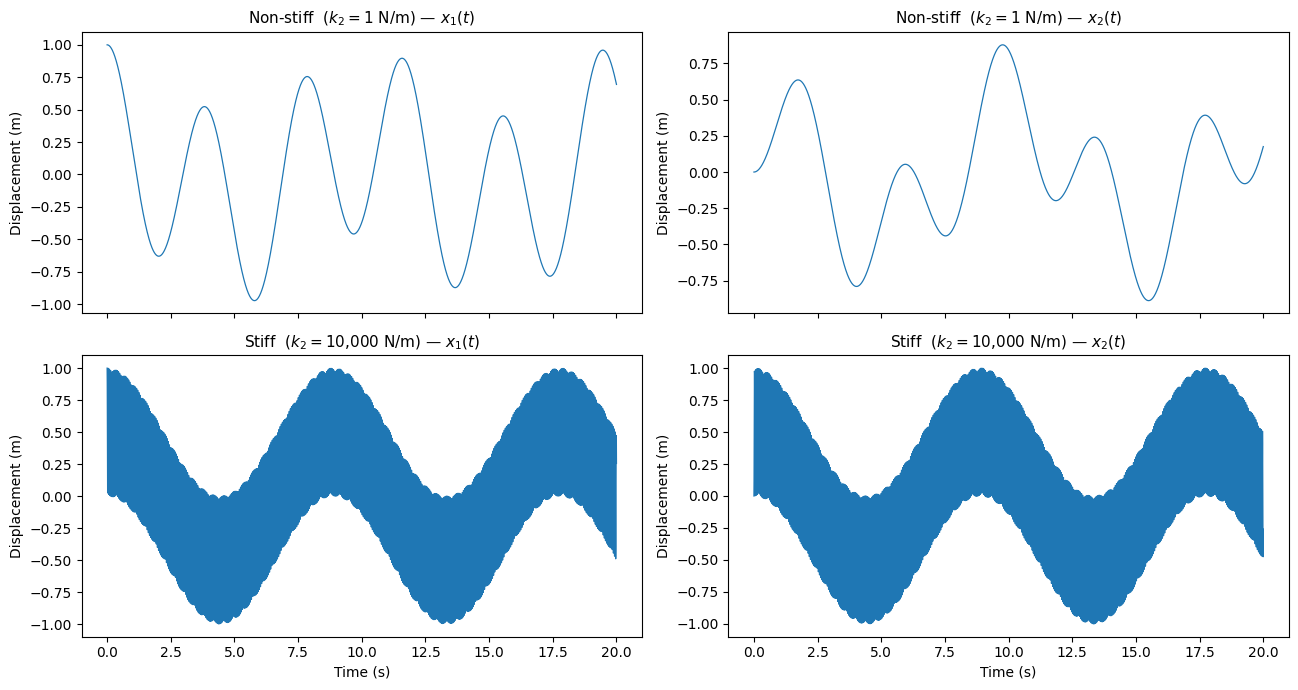

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for row, (label, sol) in enumerate([
    (r'Non-stiff  ($k_2 = 1$ N/m)',          sol_ns),
    (r'Stiff  ($k_2 = 10{,}000$ N/m)', sol_s),
]):
    for col, (idx, name) in enumerate([(0, r'$x_1(t)$'), (1, r'$x_2(t)$')]):
        ax = axes[row, col]
        ax.plot(sol.t, sol.y[idx], lw=0.9)
        ax.set_title(f'{label} — {name}', fontsize=11)
        ax.set_ylabel('Displacement (m)')
   
        if row == 1:
            ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

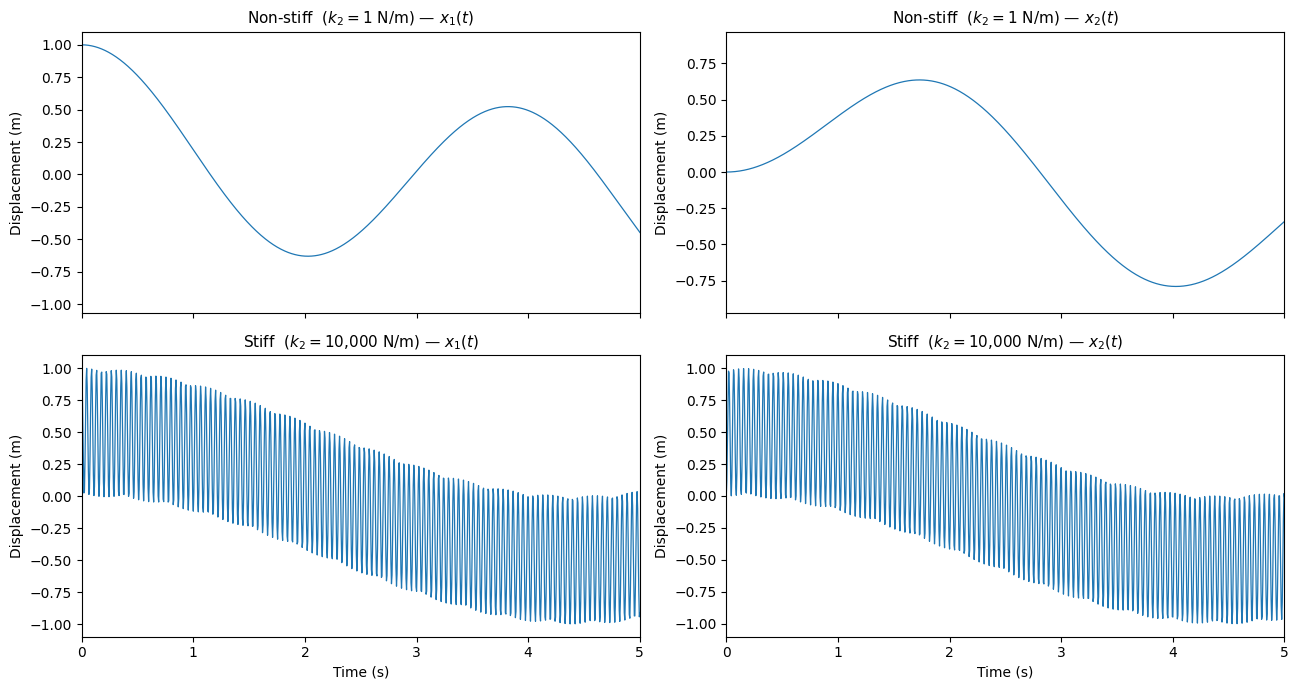

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for row, (label, sol) in enumerate([
    (r'Non-stiff  ($k_2 = 1$ N/m)',          sol_ns),
    (r'Stiff  ($k_2 = 10{,}000$ N/m)', sol_s),
]):
    for col, (idx, name) in enumerate([(0, r'$x_1(t)$'), (1, r'$x_2(t)$')]):
        ax = axes[row, col]
        ax.plot(sol.t, sol.y[idx], lw=0.9)
        ax.set_title(f'{label} — {name}', fontsize=11)
        ax.set_ylabel('Displacement (m)')
        ax.set_xlim(0,5)
        if row == 1:
            ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

The same solver with the same tolerances and the same integration time required roughly **80–100 times** more function evaluations on the stiff problem. Look at the bottom panels: the stiff solution has rapid, small-amplitude oscillations superimposed on the slow motion — these are the fast oscillations at $\omega \approx 100\;\text{rad/s}$. The `RK45` solver must take steps small enough to remain stable across these rapid oscillations, even if you only care about the slow dynamics.

This is the core cost of stiffness for an explicit solver: **the step size is controlled by stability, not by the accuracy of the solution you actually want.**

> **A note on implicit methods and oscillatory systems:** For chemical kinetics and other problems with *decaying* fast modes (large negative real eigenvalues), switching to `Radau` or `BDF` can reduce the function evaluations by orders of magnitude. The coupled spring, however, has *oscillatory* fast modes (purely imaginary eigenvalues) — a distinct and subtler flavor of stiffness where the implicit method advantage is less dramatic. In this case, an approach that conserves energy, like leapfrog or Verlet methods, would be more appropriate. The next example shows a case where implicit methods provide a decisive speedup.

---
### 3.2 Robertson chemical kinetics — the canonical stiff benchmark

A widely used benchmark problem from chemistry describes three reacting species A, B, C:

$$\frac{dy_1}{dt} = -0.04\,y_1 + 10^4\,y_2 y_3$$
$$\frac{dy_2}{dt} = 0.04\,y_1 - 10^4\,y_2 y_3 - 3\times10^7\,y_2^2$$
$$\frac{dy_3}{dt} = 3\times10^7\,y_2^2$$

The three rate constants span nine orders of magnitude ($0.04$ to $3\times10^7$), making this one of the most stiff systems in common use. The fast reaction ($3\times10^7$) reaches quasi-equilibrium almost instantaneously while the slow reactions play out over hundreds of seconds — a textbook case of decaying fast modes driving stiffness.

We solve with both `RK45` and `Radau` to compare.

In [ ]:
import time
def robertson(t, y):
    y1, y2, y3 = y
    return [
        -0.04 * y1 + 1e4  * y2 * y3,
         0.04 * y1 - 1e4  * y2 * y3 - 3e7 * y2**2,
         3e7  * y2**2,
    ]

y0_rob   = [1.0, 0.0, 0.0]
t_rob    = (0, 50)
tols_rob = dict(rtol=1e-6, atol=1e-9)

# log-spaced output times to resolve the rapid early transient
t_eval_r = np.logspace(-5, np.log10(50), 400)

# implicit solver
t1=time.time()
sol_ra = solve_ivp(robertson, t_rob, y0_rob, method='Radau',
                   t_eval=t_eval_r, **tols_rob)
t2=time.time()
print(f"Radau solver took {t2-t1:.2f} seconds")

# explicit solver (may be slow — this is the point)
t3=time.time()
sol_rk = solve_ivp(robertson, t_rob, y0_rob, method='RK45',
                   t_eval=t_eval_r, **tols_rob)
t4=time.time()
print(f"RK45 solver took {t4-t3:.2f} seconds")

print("Robertson system, t in [0, 50] s, identical tolerances")
print(f"  RK45  : {sol_rk.nfev:>8,} function evaluations")
print(f"  Radau : {sol_ra.nfev:>8,} function evaluations")
print(f"  Iterations Ratio : {sol_rk.nfev / sol_ra.nfev:.0f}x")
print(f" Speed Up Ratio: {(t4-t3) / (t2-t1):.0f}x (time)")

Radau solver took 0.01 seconds
RK45 solver took 2.10 seconds
Robertson system, t in [0, 50] s, identical tolerances
  RK45  :  317,030 function evaluations
  Radau :      569 function evaluations
  Ratio : 557x
 Speed Up Ratio: 144x (time)


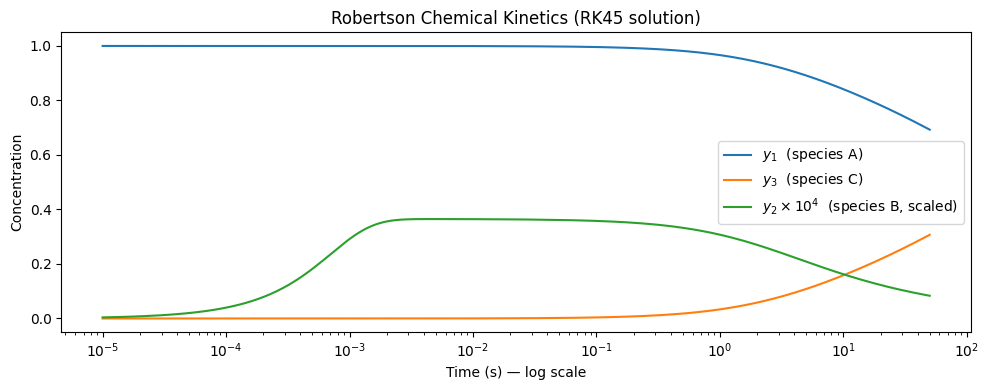

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(sol_rk.t, sol_rk.y[0],         label=r'$y_1$  (species A)')
ax.semilogx(sol_rk.t, sol_rk.y[2],         label=r'$y_3$  (species C)')
ax.semilogx(sol_rk.t, sol_rk.y[1] * 1e4,   label=r'$y_2 \times 10^4$  (species B, scaled)')
ax.set_xlabel('Time (s) — log scale')
ax.set_ylabel('Concentration')
ax.set_title('Robertson Chemical Kinetics (RK45 solution)')
ax.legend()
plt.tight_layout()
plt.show()

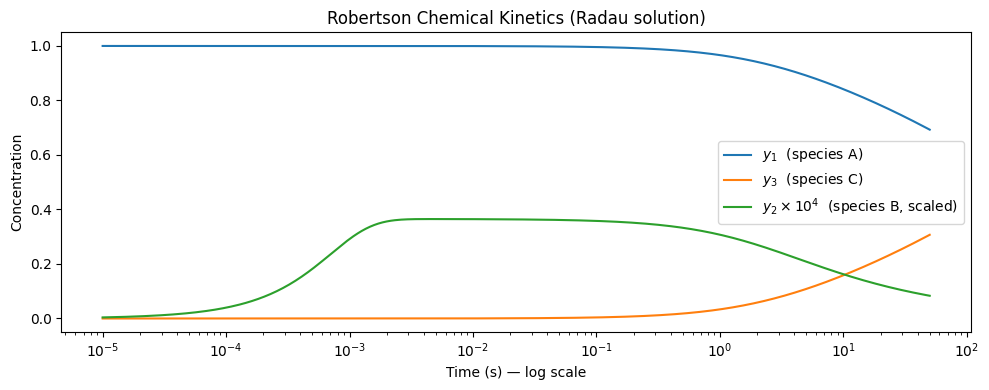

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(sol_ra.t, sol_ra.y[0],         label=r'$y_1$  (species A)')
ax.semilogx(sol_ra.t, sol_ra.y[2],         label=r'$y_3$  (species C)')
ax.semilogx(sol_ra.t, sol_ra.y[1] * 1e4,   label=r'$y_2 \times 10^4$  (species B, scaled)')
ax.set_xlabel('Time (s) — log scale')
ax.set_ylabel('Concentration')
ax.set_title('Robertson Chemical Kinetics (Radau solution)')
ax.legend()
plt.tight_layout()
plt.show()

`Radau` solves the Robertson problem in a small fraction of the function evaluations required by `RK45`. With identical tolerances, the gap is typically two to three orders of magnitude. This is the decisive advantage of implicit methods for problems with large negative real eigenvalues: `Radau` can skip over the fast-decaying transient with large steps, while `RK45` is forced by stability to take tiny steps throughout — even long after the fast mode has effectively vanished.

Note the log-spaced time axis: species B (the intermediate) peaks within the first millisecond and decays rapidly, while A converts slowly to C over tens of seconds. The solver must handle both timescales simultaneously.

---
## Part 4: Why Stability Forces Tiny Steps — and Why Implicit Methods Help

The previous section showed that explicit solvers struggle with stiff problems. This section explains *why*, and illustrates the difference between explicit and implicit methods directly.

### The solution family perspective

For the scalar test ODE $dy/dt = \lambda y$ (with $\lambda < 0$), the general solution is a family of exponential curves:

$$y(t) = c \cdot e^{\lambda t}$$

one curve for each initial condition $c$. Your numerical solver tracks the specific curve through your chosen initial condition, but at every step it introduces a small truncation error — landing you slightly off the true solution, onto a neighboring curve.

The plot below shows this solution family for a **non-stiff** ODE ($\lambda = -0.5$, left panel) and a **stiff** ODE ($\lambda = -20$, right panel). The red arrow shows where a single forward Euler step of size $h = 0.12$ takes you from the starting point $(t=0,\; y=1)$.

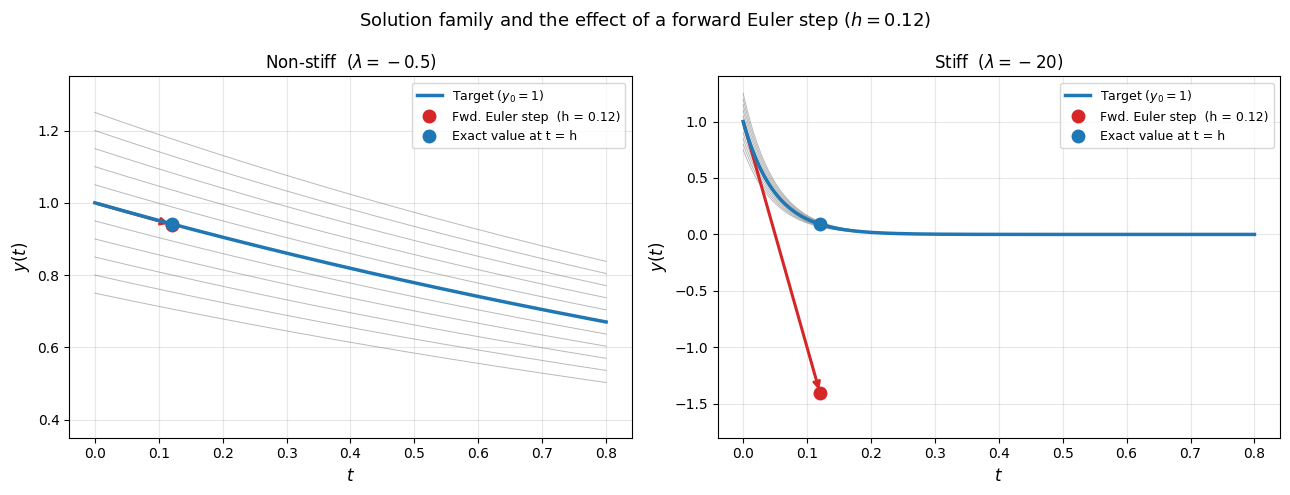

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

t_fam  = np.linspace(0, 0.8, 400)
y0_arr = np.linspace(0.75, 1.25, 11)
h_demo = 0.12

for ax, lam, title in zip(
        axes,
        [-0.5, -20],
        [r'Non-stiff  ($\lambda = -0.5$)', r'Stiff  ($\lambda = -20$)']):

    # --- solution family ---
    for y0 in y0_arr:
        if abs(y0 - 1.0) < 1e-9:
            ax.plot(t_fam, y0 * np.exp(lam * t_fam), color='C0', lw=2.5,
                    label=r'Target ($y_0 = 1$)', zorder=5)
        else:
            ax.plot(t_fam, y0 * np.exp(lam * t_fam),
                    color='gray', lw=0.7, alpha=0.55)

    # --- forward Euler step from (0, 1) ---
    y_fe = 1.0 + h_demo * lam * 1.0    # where the explicit step lands
    y_ex = np.exp(lam * h_demo)         # exact value at t = h

    ax.annotate('', xy=(h_demo, y_fe), xytext=(0.0, 1.0),
                arrowprops=dict(arrowstyle='->', color='C3', lw=2.2))
    ax.plot(h_demo, y_fe, 'o', color='C3', ms=9, zorder=10,
            label=f'Fwd. Euler step  (h = {h_demo})')
    ax.plot(h_demo, y_ex, 'o', color='C0', ms=9, zorder=10,
            label='Exact value at t = h')

    ax.set_xlabel('$t$', fontsize=12)
    ax.set_ylabel('$y(t)$', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylim(0.35, 1.35)
axes[1].set_ylim(-1.8,  1.4)   # room for the forward Euler overshoot at y = -1.4

plt.suptitle(r'Solution family and the effect of a forward Euler step ($h = 0.12$)', fontsize=13)
plt.tight_layout()
plt.show()

**Left panel (non-stiff, $\lambda = -0.5$):** A forward Euler step of $h = 0.12$ lands at $y = 1 + 0.12 \times (-0.5) \times 1 = 0.94$, almost exactly on top of the true value $e^{-0.06} \approx 0.942$ (the red and blue dots nearly coincide). A small error simply puts you on a nearby, similar-looking curve. Explicit methods work fine here.

**Right panel (stiff, $\lambda = -20$):** The same step of $h = 0.12$ produces $y = 1 + 0.12 \times (-20) \times 1 = -1.4$, far below the true value ($e^{-2.4} \approx 0.091$) and below the entire family of neighboring solutions, all of which have collapsed to near zero by $t = 0.12$. The solver has not just landed on the wrong curve — it has jumped outside the entire physical solution family.

---

### Why this happens: the amplification factor

For forward Euler applied to $y' = \lambda y$, the update rule is:

$$y_{n+1} = y_n \cdot (1 + h\lambda)$$

The factor $(1 + h\lambda)$ is the **amplification factor**. For the numerical solution to remain bounded, we need $|1 + h\lambda| < 1$. With $\lambda = -20$, this requires:

$$|1 - 20h| < 1 \quad \Longrightarrow \quad h < 0.1\;\text{s}$$

Yet the true solution $e^{-20t}$ is smooth and slowly varying after the first fraction of a second — accuracy alone might permit steps of $h = 0.5$ or larger. **The gap between what accuracy demands and what stability demands is exactly the definition of stiffness.**

Every explicit method has a finite **stability region** in the complex plane: the set of values $h\lambda$ for which the method does not produce growing errors. For `RK45` on the real axis, this extends to roughly $h\lambda \approx -3.5$. For a large negative eigenvalue, this hard boundary forces the step size down regardless of how smoothly the slow solution is behaving. For purely imaginary eigenvalues (like the undamped spring), the stability region of `RK45` on the imaginary axis extends to roughly $\pm 2.8i$, similarly constraining the step size.

---

### Why implicit methods escape this constraint

For **backward Euler**, the update rule is found by solving the implicit equation:

$$y_{n+1} = y_n + h \cdot \lambda \, y_{n+1} \quad\Longrightarrow\quad y_{n+1} = \frac{y_n}{1 - h\lambda}$$

For any $\lambda < 0$ and any step size $h > 0$, the denominator $(1 - h\lambda) = (1 + h|\lambda|) > 1$, so $|y_{n+1}| < |y_n|$ — **the method is unconditionally stable.** The stability region of backward Euler (and, more generally, of `Radau` and `BDF`) covers the entire left half-plane. A step of any size remains bounded.

The tradeoff is accuracy: larger steps give less accurate solutions (though always stable and physically sensible). For stiff problems with decaying fast modes, taking a few large implicit steps — each requiring Newton iteration, a method of solving equations — is almost always cheaper than taking many thousands of tiny explicit steps.

The next plot demonstrates this directly on the test problem $dy/dt = -20\,y$.

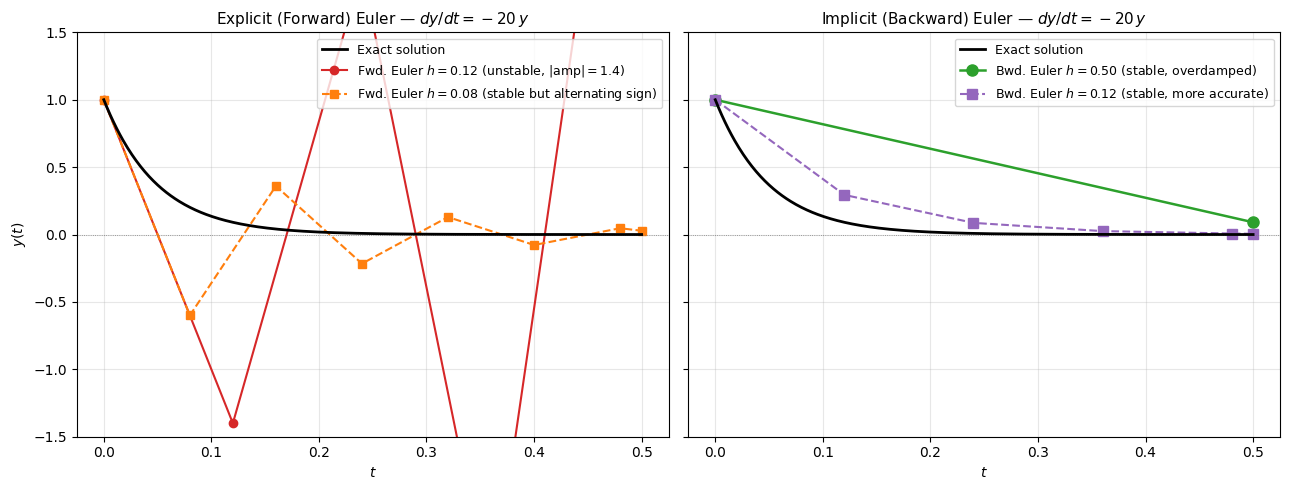

In [6]:
lam    = -20.0
t_end  = 0.5
t_fine = np.linspace(0, t_end, 500)

def exact(t):
    return np.exp(lam * t)

def forward_euler(h):
    t_vals, y_vals = [0.0], [1.0]
    while t_vals[-1] < t_end - 1e-12:
        h_act = min(h, t_end - t_vals[-1])
        t_vals.append(t_vals[-1] + h_act)
        y_vals.append(y_vals[-1] * (1.0 + h_act * lam))
    return np.array(t_vals), np.array(y_vals)

def backward_euler(h):
    # solve y_{n+1} = y_n / (1 - h*lam) analytically for the linear test case
    t_vals, y_vals = [0.0], [1.0]
    while t_vals[-1] < t_end - 1e-12:
        h_act = min(h, t_end - t_vals[-1])
        t_vals.append(t_vals[-1] + h_act)
        y_vals.append(y_vals[-1] / (1.0 - h_act * lam))
    return np.array(t_vals), np.array(y_vals)

# stability limit for forward Euler: |1 + h*lam| < 1  =>  h < 2/|lam| = 0.10
t_fu, y_fu = forward_euler(0.12)    # just above the stability threshold -> unstable
t_fs, y_fs = forward_euler(0.08)    # below the threshold -> stable but alternating sign
t_bl, y_bl = backward_euler(0.50)   # five times the explicit stability limit -> stable
t_bm, y_bm = backward_euler(0.12)   # same step as the unstable explicit case -> stable

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# --- Left: explicit methods ---
ax = axes[0]
ax.plot(t_fine, exact(t_fine), 'k-', lw=2, label='Exact solution', zorder=5)
ax.plot(t_fu, y_fu, 'o-', color='C3', ms=6, lw=1.5,
        label=r'Fwd. Euler $h=0.12$ (unstable, $|$amp$|=1.4$)')
ax.plot(t_fs, y_fs, 's--', color='C1', ms=6, lw=1.5,
        label=r'Fwd. Euler $h=0.08$ (stable but alternating sign)')
ax.axhline(0, color='gray', lw=0.6, ls=':')
ax.set_title(r'Explicit (Forward) Euler — $dy/dt = -20\,y$', fontsize=11)
ax.set_xlabel('$t$')
ax.set_ylabel('$y(t)$')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Right: implicit methods ---
ax = axes[1]
ax.plot(t_fine, exact(t_fine), 'k-', lw=2, label='Exact solution', zorder=5)
ax.plot(t_bl, y_bl, 'o-', color='C2', ms=8, lw=1.8,
        label=r'Bwd. Euler $h=0.50$ (stable, overdamped)')
ax.plot(t_bm, y_bm, 's--', color='C4', ms=7, lw=1.5,
        label=r'Bwd. Euler $h=0.12$ (stable, more accurate)')
ax.axhline(0, color='gray', lw=0.6, ls=':')
ax.set_title(r'Implicit (Backward) Euler — $dy/dt = -20\,y$', fontsize=11)
ax.set_xlabel('$t$')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

axes[0].set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()

**Left panel (explicit):** With $h = 0.12$ — just above the stability threshold of 0.10 — the forward Euler solution oscillates and grows without bound. With $h = 0.08$ (below the threshold), it is bounded, but alternates sign on every step: the numerical solution goes negative even though the exact solution $e^{-20t}$ is always positive. Neither behavior is physically meaningful, and both stem from stability constraints, not accuracy requirements.

**Right panel (implicit):** Backward Euler with $h = 0.12$ produces a smooth, monotone, always-positive solution — the correct qualitative behavior — though it decays more slowly than the exact solution (an accuracy issue, not a stability one). With $h = 0.50$ — five times the stability limit for forward Euler — it is still bounded and positive. Both implicit solutions are physically sensible; accuracy improves with smaller $h$, but stability is never at risk.

---

### Summary

| | Explicit (`RK45`) | Implicit (`Radau`, `BDF`) |
|:--|:--|:--|
| **Stability region** | Finite (small) | Entire left half-plane |
| **Step size on stiff problems** | Must be tiny (stability-limited) | Can be large |
| **Cost per step** | Cheap (direct formula) | More expensive (Newton iteration) |
| **Net cost on decaying stiff problems** | Very high | Much lower |

For stiff problems with fast-decaying modes, always try `Radau` or `BDF`. As a practical first diagnostic, compare `sol.nfev` between `RK45` and `Radau` with identical tolerances — a large ratio is a reliable sign of stiffness.


As for the coupled spring problem, the lack of a symplectic solver (one that conserves energy) in Scipy is a [known gap](https://github.com/scipy/scipy/issues/12690). There are other Python libraries out there that do have symplectic solvers, but they are not as widely used, as well-documented, or as well-maintained as the Scipy functions.